In [186]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
import os
import sys 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from pandas_plink import read_plink1_bin
import glob
from sklearn.preprocessing import StandardScaler


In [ ]:
DATA = "UKB_CRC"

In [ ]:
G = read_plink1_bin(f"data/qc/{DATA}.QC.bed", f"data/qc/{DATA}.QC.bim", f"data/qc/{DATA}.QC.fam", verbose=False)

In [ ]:
labels = pd.read_csv(f"data/raw/{DATA}/{DATA}.pheno", sep='\t')  # columns: iid, phenotype

In [189]:
labels.head()

,FID,IID,phenotype
0,1000302,1000302,1
1,1000341,1000341,1
2,1000655,1000655,1
3,1001549,1001549,1
4,1003416,1003416,1


In [ ]:
prcise_df = pd.read_csv(f"data/results/{DATA}/prsice/prsice.best", sep=" ")

In [191]:
prcise_df.head()

,FID,IID,In_Regression,PRS
0,1000302,1000302,Yes,0.000349
1,1000341,1000341,Yes,0.000281
2,1000655,1000655,Yes,0.000444
3,1001549,1001549,Yes,0.000226
4,1003416,1003416,Yes,0.000348


In [ ]:
lassosum_df = pd.read_csv(f"data/results/{DATA}/lassosum/_PRS.csv", sep=",")

In [193]:
lassosum_df.head()

,FID,IID,PRS
0,1000302,1000302,0.359398
1,1000341,1000341,-0.288984
2,1000655,1000655,0.191542
3,1001549,1001549,0.267061
4,1003416,1003416,0.188540


In [ ]:
lassosum2_df = pd.read_csv(f"data/results/{DATA}/lassosum2/lassosum2_PRS.csv", sep=",")

In [195]:
lassosum2_df.head()

,FID,IID,PRS
0,1000302,1000302,8.232219
1,1000341,1000341,5.695716
2,1000655,1000655,10.347025
3,1001549,1001549,5.019577
4,1003416,1003416,9.123775


In [ ]:
LDpred2_df = pd.read_csv(f"data/results/{DATA}/ldpred2/ldpred2_PRS.csv", sep=",")

In [197]:
LDpred2_df.head()

,FID,IID,PRS
0,1000302,1000302,2.641602
1,1000341,1000341,2.140763
2,1000655,1000655,4.294722
3,1001549,1001549,-0.808011
4,1003416,1003416,1.235010


In [ ]:
sct_df = pd.read_csv(f"data/results/{DATA}/sct/sct_PRS.csv", sep=",")

In [199]:
sct_df.head()

,FID,IID,PRS,is_train
0,1000302,1000302,3.897955,True
1,1000341,1000341,3.001322,True
2,1000655,1000655,5.179523,True
3,1001549,1001549,2.487803,True
4,1003416,1003416,4.163964,True


In [ ]:
sbayes_betas = pd.read_csv(f"data/results/{DATA}/sbayesr/sbayesr_model_sbrc.txt", sep="\t")

In [201]:
#rename columns
sbayes_betas.columns = ["snp", "a0", "beta", "se", "pip", "betalast"]

In [202]:
sbayes_betas.head()

,snp,a0,beta,se,pip,betalast
0,rs4970383,A,0.066910,0.335661,0.2010,0.0
1,rs4475691,T,0.048614,0.329963,0.1540,0.0
2,rs1806509,A,-0.027442,0.347011,0.2930,0.0
3,rs7537756,G,0.050368,0.392434,0.2500,0.0
4,rs13302982,G,0.023307,0.611954,0.0955,0.0


In [ ]:
# PRS-CS

files = glob.glob(f'data/results/{DATA}/prs_cs/*.txt')
prs_cs_betas = pd.concat([pd.read_csv(f, sep="\t", header=None) for f in files], ignore_index=True)

prs_cs_betas.columns = ["chr", "snp", "pos", "a0", "a1", "beta"]


In [204]:
prs_cs_betas.head()

,chr,snp,pos,a0,a1,beta
0,8,rs17665364,365789,T,C,-0.001482
1,8,rs6994245,565639,C,T,-0.000534
2,8,rs11777864,828266,G,A,0.000752
3,8,rs2701923,994605,C,T,-0.000591
4,8,rs4735837,1037264,T,C,-0.000407


In [ ]:
# PRS-CSx   

files = glob.glob(f'data/results/{DATA}/prs_csx/*.txt')
prs_csx_betas = pd.concat([pd.read_csv(f, sep="\t", header=None) for f in files], ignore_index=True)

prs_csx_betas.columns = ["chr", "snp", "pos", "a0", "a1", "beta"]

In [206]:
prs_csx_betas.head()

,chr,snp,pos,a0,a1,beta
0,4,rs11730564,514201,T,G,0.000703
1,4,rs12646225,696848,T,C,-0.001084
2,4,rs2306242,843720,C,T,0.001030
3,4,rs615381,1087531,C,T,-0.001109
4,4,rs13142085,1348020,T,C,0.002430


In [207]:
# calculate PRS for missing models

bim = G.coords
bim_df = pd.DataFrame({
    'snp': G.variant.snp.values,
    'a0':  G.variant.a0.values,   # reference allele
    'a1':  G.variant.a1.values,   # alternative allele
    'i':   np.arange(G.shape[1])  # column index
})

In [208]:
merged_sbayes = sbayes_betas.merge(bim_df, on='snp', suffixes=('_sbayes', '_bim'))
aligned_sbayes = merged_sbayes[merged_sbayes['a0_sbayes'] == merged_sbayes['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_sbayes['i'].values
betas   = aligned_sbayes['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_sbayes = G_sub @ betas  # shape: (n_samples,)

# Package results
sbayes_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_sbayes
})

In [209]:
sbayes_df.head()

,IID,FID,PRS
0,1000302,1000302,1079.820559
1,1000341,1000341,1084.412830
2,1000655,1000655,1081.539105
3,1001549,1001549,1077.358782
4,1003416,1003416,1081.776626


In [ ]:
sbayes_betas = pd.read_csv(f"data/results/{DATA}/sbayesr/prs_sbrc.profile", sep='\s+')

sbayes_df = sbayes_betas[['IID', 'FID', 'SCORE']].copy()
sbayes_df.columns = ['IID', 'FID', 'PRS']

In [211]:
sbayes_df.head()

,IID,FID,PRS
0,1000302,1000302,0.009239
1,1000341,1000341,0.009091
2,1000655,1000655,0.009203
3,1001549,1001549,0.009300
4,1003416,1003416,0.009187


In [212]:
merged_cs = prs_cs_betas.merge(bim_df, on='snp', suffixes=('_cs', '_bim'))
aligned_cs = merged_cs[merged_cs['a0_cs'] == merged_cs['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_cs['i'].values
betas   = aligned_cs['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_cs = G_sub @ betas  # shape: (n_samples,)

# Package results
cs_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_cs
})

In [213]:
cs_df.head()

,IID,FID,PRS
0,1000302,1000302,-0.201292
1,1000341,1000341,-0.177904
2,1000655,1000655,-0.268510
3,1001549,1001549,-0.095469
4,1003416,1003416,-0.167145


In [214]:
merged_cs_x = prs_csx_betas.merge(bim_df, on='snp', suffixes=('_cs', '_bim'))
aligned_cs_x = merged_cs_x[merged_cs_x['a0_cs'] == merged_cs_x['a0_bim']].copy()

# Extract genotype matrix for matched SNPs
indices = aligned_cs_x['i'].values
betas   = aligned_cs_x['beta'].values

# Load into memory as numpy (can be large — chunk if needed)
G_sub = G[:, indices].values  # shape: (n_samples, n_snps)

prs_cs_x = G_sub @ betas  # shape: (n_samples,)

# Package results
cs_x_df = pd.DataFrame({
    'IID': G.sample.iid.values,
    'FID': G.sample.fid.values,
    'PRS': prs_cs_x
})

In [215]:
cs_x_df.head()

,IID,FID,PRS
0,1000302,1000302,-0.182736
1,1000341,1000341,-0.171744
2,1000655,1000655,-0.249904
3,1001549,1001549,-0.104228
4,1003416,1003416,-0.152066


In [ ]:
folds = []

for fold in os.listdir(f"data/qc/{DATA}/folds/folds/"):
    fold_path = os.path.join(f"data/qc/{DATA}/folds/folds/", fold)
    fold_iids = pd.read_csv(fold_path, sep=" ")
    fold_iids = fold_iids['IID'].tolist()  # convert to list of iids
    print(len(fold_iids))
    folds.append(fold_iids)



783
783
783
784
784
784
783
784
783
783


In [217]:
prs_dfs = [ prcise_df, lassosum_df, lassosum2_df, LDpred2_df, sct_df, sbayes_df, cs_df, cs_x_df]

In [218]:
prs_names = ["PRSice", "Lassosum", "Lassosum2", "LDpred2", "SCT", "SBayesR", "PRS-CS", "PRS-CSx"]

In [219]:
# make all IID columns int and all PRS columns float
for df in prs_dfs:
    df['IID'] = df['IID'].astype(int)
    df['PRS'] = df['PRS'].astype(float)    

In [220]:
prs_merged = labels[['IID', 'phenotype']].copy()

for i, df in enumerate(prs_dfs):
    df = df.rename(columns={'PRS': f'PRS_{prs_names[i]}'})
    prs_merged = prs_merged.merge(df[['IID', f'PRS_{prs_names[i]}']], on='IID', how='inner')

prs_features = [f'PRS_{name}' for name in prs_names]
print(prs_merged.shape)

(7834, 10)


In [221]:
# --- K-Fold CV: train separate LR per PRS model, evaluate AUC ---

results = {f'PRS_{prs_names}': [] for prs_names in prs_names}  # AUC per fold per model
results['ensemble'] = []  # optional: LR trained on all 8 features

for fold_idx, test_ids in enumerate(folds):
    test_mask  = prs_merged['IID'].isin(test_ids)
    train_mask = ~test_mask

    train_df = prs_merged[train_mask]
    test_df  = prs_merged[test_mask]

    y_train = train_df['phenotype'].values
    y_test  = test_df['phenotype'].values

    # --- Per-model LR ---
    for feature in prs_features:
        X_train = train_df[[feature]].values
        X_test  = test_df[[feature]].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_train, y_train)

        auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
        results[feature].append(auc)

    # --- Ensemble LR (all 8 PRS as features) ---
    X_train_all = train_df[prs_features].values
    X_test_all  = test_df[prs_features].values

    scaler = StandardScaler()
    X_train_all = scaler.fit_transform(X_train_all)
    X_test_all  = scaler.transform(X_test_all)

    lr_ens = LogisticRegression(max_iter=1000)
    lr_ens.fit(X_train_all, y_train)

    auc_ens = roc_auc_score(y_test, lr_ens.predict_proba(X_test_all)[:, 1])
    results['ensemble'].append(auc_ens)

    print(f"Fold {fold_idx+1} done")

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
Fold 6 done
Fold 7 done
Fold 8 done
Fold 9 done
Fold 10 done


In [222]:
# --- Summarise results ---
summary = pd.DataFrame(results)
summary.index = [f'Fold_{i+1}' for i in range(len(folds))]
summary.loc['Mean'] = summary.mean()
summary.loc['Std']  = summary.std()

print(summary.round(4))

         PRS_PRSice  PRS_Lassosum  PRS_Lassosum2  PRS_LDpred2  PRS_SCT  \
Fold_1       0.9515        0.7251         0.9514       0.9321   0.9539   
Fold_2       0.9225        0.7224         0.9256       0.9082   0.9274   
Fold_3       0.9402        0.7137         0.9426       0.9283   0.9429   
Fold_4       0.9350        0.7367         0.9397       0.9250   0.9435   
Fold_5       0.9455        0.7395         0.9436       0.9242   0.9497   
Fold_6       0.9409        0.7600         0.9391       0.9305   0.9436   
Fold_7       0.9326        0.7431         0.9398       0.9216   0.9405   
Fold_8       0.9364        0.7223         0.9330       0.9161   0.9397   
Fold_9       0.9484        0.7161         0.9447       0.9432   0.9479   
Fold_10      0.9454        0.7623         0.9498       0.9393   0.9476   
Mean         0.9399        0.7341         0.9409       0.9269   0.9437   
Std          0.0081        0.0164         0.0072       0.0098   0.0068   

         PRS_SBayesR  PRS_PRS-CS  PRS

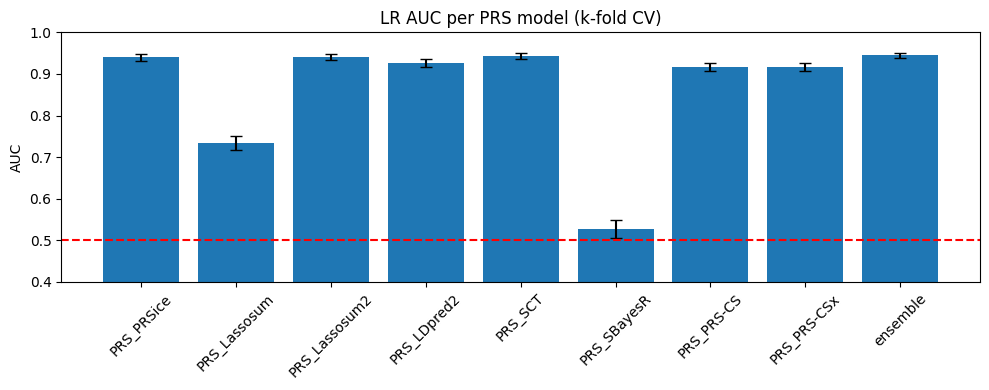

In [223]:
# --- Optional: visualise ---
import matplotlib.pyplot as plt

means = summary.loc['Mean']
stds  = summary.loc['Std']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(means.index, means.values, yerr=stds.values, capsize=4)
ax.axhline(0.5, color='red', linestyle='--', label='Random')
ax.set_ylabel('AUC')
ax.set_title('LR AUC per PRS model (k-fold CV)')
ax.set_ylim(0.4, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('prs_lr_auc.png', dpi=150)
plt.show()